In [1]:
from typing import List
from datetime import date
from sqlalchemy import String, Integer, ForeignKey, DECIMAL, Date
from sqlalchemy.orm import DeclarativeBase, Mapped, mapped_column, relationship
from sqlalchemy import create_engine, inspect, select
from sqlalchemy.orm import Session
from sqlalchemy import inspect
from sqlalchemy import text
import os
from pathlib import Path
import pandas as pd
from dotenv import load_dotenv
from adbc_driver_postgresql import dbapi
import pandas as pd
import os
import plotly.express as px
import plotly.io as pio
import pandas as pd
pd.options.plotting.backend = 'plotly'
pio.templates.default = 'plotly_dark+presentation'

# --- Configuration ---
BASE_DIR = Path('./')
ENV_PATH = BASE_DIR / "creds.env"
load_dotenv(dotenv_path=ENV_PATH)

DB_USER = os.getenv("DB_USER", "postgres")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_NAME = os.getenv("DB_NAME", "unarxive")

CONNECTION_STRING = f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}/{DB_NAME}"
engine = create_engine(CONNECTION_STRING)

In [2]:
def run_query(query: str, engine=engine) -> pd.DataFrame:
  return pd.read_sql(query, engine)

In [3]:
import pandas as pd

sql = """
    SELECT *
    FROM g_us_application_citation_1
    LIMIT 20
"""
g_us_app_df = pd.read_sql(text(sql), engine)
display(g_us_app_df)

,patent_id,citation_sequence,citation_document_number,citation_date,record_name,wipo_kind,citation_category
0,8102431,0,20070236734,2007-10-01,Okamoto,A1,cited by examiner
1,8117225,0,20040158607,2004-08-01,Coppinger et al.,A1,cited by other
2,8717974,0,20070229270,2007-10-01,Rofougaran,A1,cited by applicant
3,8182067,0,20040036751,2004-02-01,Giere et al.,A1,cited by examiner
4,10629046,104,20120212582,2012-08-01,Deutsch,A1,cited by applicant
5,10463372,810,20170007243,2017-01-01,"Shelton, IV et al.",A1,cited by applicant
6,9239722,0,20040199489,2004-10-01,Barnes-Leon et al.,A1,cited by applicant
7,7934038,0,20030198224,2003-10-01,Lee et al.,A1,cited by other
8,9984872,151,20080257409,2008-10-01,Li et al.,A1,cited by applicant
9,10874097,6,20130212924,2013-08-01,Shisko,A1,cited by applicant


In [4]:

sql = """
    SELECT 
        l.disambig_country as country,
        COUNT(DISTINCT i.patent_id) as patent_count
    FROM g_location_disambiguated l
    JOIN g_inventor_disambiguated i ON l.location_id = i.location_id
    GROUP BY l.disambig_country
    ORDER BY patent_count DESC
    LIMIT 10
"""

# Read directly into a DataFrame
df = pd.read_sql(text(sql), engine)
df

,country,patent_count
0,US,4872110
1,JP,1548661
2,DE,582182
3,KR,406379
4,CN,390174
5,TW,291047
6,GB,254358
7,FR,239515
8,CA,234095
9,CH,110156


In [5]:
sql = """
    SELECT 
        l.disambig_city as city,
        COUNT(DISTINCT i.patent_id) as patent_count
    FROM g_location_disambiguated l
    JOIN g_inventor_disambiguated i ON l.location_id = i.location_id
    GROUP BY l.disambig_city
    ORDER BY patent_count DESC
    LIMIT 20
"""

# Read directly into a DataFrame
city_df = pd.read_sql(text(sql), engine)
display(city_df)

,city,patent_count
0,Tokyo,362553
1,Yokohama,280871
2,San Jose,212180
3,Seoul,184723
4,San Francisco,128614
5,San Diego,113279
6,Sunnyvale,109027
7,Osaka,97441
8,Kawasaki,93571
9,Taipei,90553


In [6]:
sql = """
    SELECT 
        i.inventor_id,
        i.disambig_inventor_name_first as first_name,
        i.disambig_inventor_name_last as last_name,
        COUNT(DISTINCT i.patent_id) as patent_count
    FROM g_inventor_disambiguated i
    GROUP BY i.inventor_id, i.disambig_inventor_name_first, i.disambig_inventor_name_last
    ORDER BY patent_count DESC
    LIMIT 10
"""

inventor_df = pd.read_sql(text(sql), engine)
display(inventor_df)

,inventor_id,first_name,last_name,patent_count
0,fl:sh_ln:yamazaki-55,Shunpei,Yamazaki,6761
1,fl:ki_ln:silverbrook-1,Kia,Silverbrook,4778
2,fl:ta_ln:luo-5,Tao,Luo,4336
3,fl:jo_ln:ive-4,Jonathan P.,Ive,2877
4,fl:ka_ln:cheng-90,Kangguo,Cheng,2819
5,fl:ju_ln:li-39,Junyi,Li,2789
6,fl:fr_ln:shelton-6,Frederick E.,"Shelton, IV",2670
7,fl:pe_ln:gaal-1,Peter,Gaal,2504
8,fl:du_ln:kerr-1,Duncan Robert,Kerr,2466
9,fl:ba_ln:andre-6,Bartley K.,Andre,2412


In [7]:
sql = """
    SELECT
        a.assignee_id,
        a.disambig_assignee_organization as organization,
        COUNT(DISTINCT a.patent_id) as patent_count
    FROM g_assignee_disambiguated a
    GROUP BY a.assignee_id, a.disambig_assignee_organization
    ORDER BY patent_count DESC
    LIMIT 12
"""

assignee_df = pd.read_sql(text(sql), engine)
display(assignee_df)

,assignee_id,organization,patent_count
0,d1d96a91-c5e6-4090-ba39-4af2494eb35c,"SAMSUNG ELECTRONICS CO., LTD.",171950
1,6e80a706-ca3c-437b-8a9c-aae8b5efba57,International Business Machines Corporation,163546
2,61d52265-4aea-4f20-b743-c4a9faef6860,Canon Kabushiki Kaisha,90662
3,af1c1db8-dc03-4036-a732-d81d2ad09c0c,SONY GROUP CORPORATION,62652
4,c9398d69-5dbb-4b06-b9ea-757038ca0ea3,FUJITSU LIMITED,56293
5,a90e9fd0-52e6-43d3-b861-4a87a6e54cb8,Kabushiki Kaisha Toshiba,53438
6,47cd060e-60ce-49ab-8623-caf34f5c3860,Intel Corporation,52745
7,c743e7d8-5290-412a-aeeb-edef2348822a,General Electric Company,51898
8,f71249de-0cfb-488f-8a27-f3861dc2d67b,LG ELECTRONICS INC.,49439
9,6326da5f-8cb5-4e23-8929-4dd62cba64d3,"HITACHI, LTD.",46007


In [13]:
sql = """
    SELECT 
    EXTRACT(YEAR FROM TO_DATE(patent_date, 'YYYY-MM-DD')) AS year,
    COUNT(*) AS patent_count
    FROM g_patent
    GROUP BY EXTRACT(YEAR FROM TO_DATE(patent_date, 'YYYY-MM-DD'))
    ORDER BY patent_count DESC
"""

patent_year_df = pd.read_sql(text(sql), engine)
display(patent_year_df)

,year,patent_count
0,2019.0,392618
1,2020.0,390572
2,2024.0,373852
3,2021.0,363829
4,2022.0,360417
5,2017.0,352587
6,2023.0,350093
7,2018.0,341104
8,2016.0,334674
9,2014.0,327014


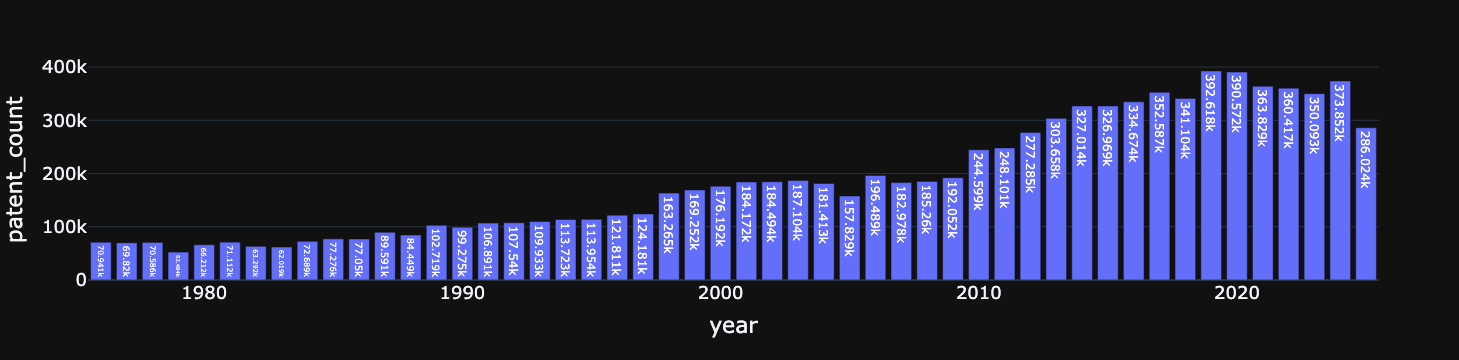

In [17]:
patent_year_df.sort_values(by="year").plot.bar(x="year", y="patent_count", text_auto=True)